# Libraries

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Configuration

In [22]:
BASE_DIR = 'eval/xquad_xlmr/625'

# Visualization

In [23]:
# Dynamically get all metrics.csv files
csv_paths = sorted(Path(BASE_DIR).glob('**/metrics.csv'))
csv_paths = [str(p) for p in csv_paths] # make string paths
print(f"CSV paths: {csv_paths}")

CSV paths: ['eval/xquad_xlmr/625/alxxtexxr/XLM-R-Base-squad-en-5K-LoRA-Merged-v260711104723/metrics.csv', 'eval/xquad_xlmr/625/alxxtexxr/XLM-R-Base-squad-vi-5K-LoRA-Addition-v260712125532/metrics.csv']


In [24]:
# Read the CSV files and concatenate them into a single DataFrame
df = pd.concat([pd.read_csv(p) for p in csv_paths], 
               keys=csv_paths, 
               names=['csv_path', None]).reset_index(level=0)

# Add a new column 'model' to the DataFrame by extracting the model name from the CSV path
df['model'] = df['csv_path'].apply(lambda p: os.path.basename(os.path.dirname(p)))

# Display the first few rows of the DataFrame to verify the data
df.head()

,csv_path,lang,test_loss,test_exact_match,test_f1,test_model_preparation_time,test_runtime,test_samples_per_second,test_steps_per_second,model
0,eval/xquad_xlmr/625/alxxtexxr/XLM-R-Base-squad...,en,1.775485,44.32,55.217763,0.0027,12.9690,48.192,3.084,XLM-R-Base-squad-en-5K-LoRA-Merged-v260711104723
1,eval/xquad_xlmr/625/alxxtexxr/XLM-R-Base-squad...,ar,2.574243,28.48,40.944926,0.0027,15.2575,40.963,2.622,XLM-R-Base-squad-en-5K-LoRA-Merged-v260711104723
2,eval/xquad_xlmr/625/alxxtexxr/XLM-R-Base-squad...,de,2.175390,36.64,48.369166,0.0027,13.7228,45.545,2.915,XLM-R-Base-squad-en-5K-LoRA-Merged-v260711104723
3,eval/xquad_xlmr/625/alxxtexxr/XLM-R-Base-squad...,el,2.505148,31.36,41.652801,0.0027,15.1818,41.168,2.635,XLM-R-Base-squad-en-5K-LoRA-Merged-v260711104723
4,eval/xquad_xlmr/625/alxxtexxr/XLM-R-Base-squad...,es,2.119809,37.76,48.274322,0.0027,14.0016,44.638,2.857,XLM-R-Base-squad-en-5K-LoRA-Merged-v260711104723


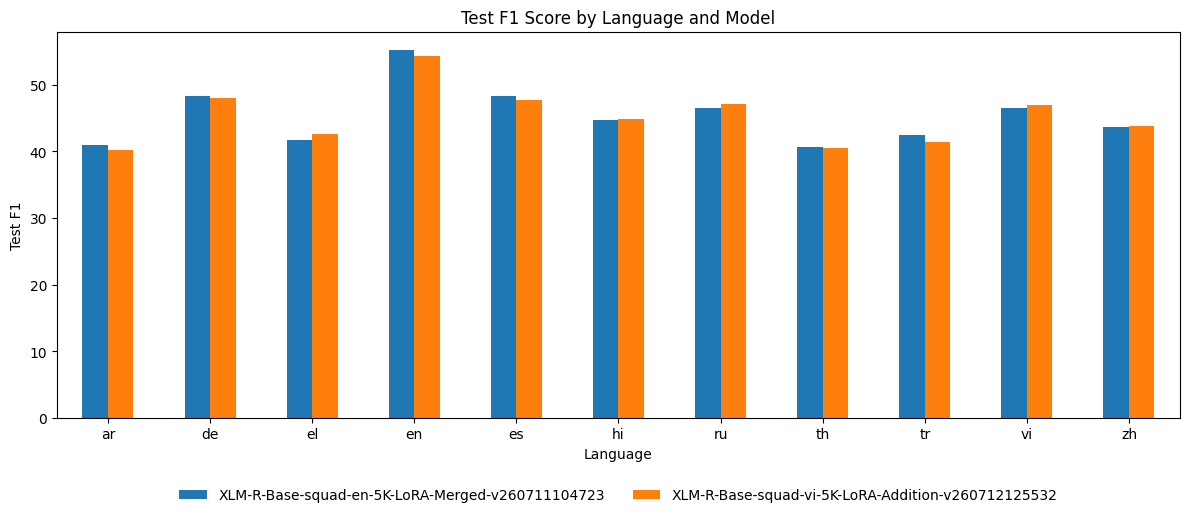

In [25]:
# Plot with pandas pivot table
pivot = df.pivot(index='lang', columns='model', values='test_f1')
ax = pivot.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('Test F1 Score by Language and Model')
plt.ylabel('Test F1')
plt.xlabel('Language')

# Move the legend below the plot, centered
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),    # (x, y) in axes coordinates; negative y pushes it below
    ncol=2,                         # two columns if you want to save horizontal space
    frameon=False,                  # optional: cleaner look without border
)

# Adjust the layout to make room for the legend
plt.tight_layout(rect=[0, 0.1, 1, 1])   # leave 10% of figure height at the bottom
plt.show()